# Phase 3: Forward/Inverse RG Demo

This notebook demonstrates the new Phase 3 pipeline:

1. Train a **forward RG hypernetwork** that maps fine Wilson couplings $J_f$ to coarse couplings $J_c$ and a blocker code $z_\phi$.
2. Freeze the forward model and train an **inverse RG proposal net** that lifts coarse lattices back to fine lattices.
3. Check single-step **round-trip consistency** by blocking the generated fine sample back to the coarse lattice.

The notebook intentionally uses a tiny lattice and very short training runs so it stays runnable as a smoke demo.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from inverserg.forward_rg import ForwardRGConfig, train_forward_rg
from inverserg.inverse import InverseRGConfig, inverse_rg_step, train_inverse_rg
from inverserg.training import RGTrainingConfig, generate_fine_ensemble

torch.manual_seed(7)

BETA_GRID = [2.0, 3.0]
DEMO_BETA = 3.0
FINE_L = 4
N_SAMPLES = 4
FORWARD_EPOCHS = 4
INVERSE_EPOCHS = 4

print(f"Beta grid: {BETA_GRID}")
print(f"Demo beta: {DEMO_BETA}")
print(f"Fine lattice size: {FINE_L}")
print(f"Samples per beta: {N_SAMPLES}")

Beta grid: [2.0, 3.0]
Demo beta: 3.0
Fine lattice size: 4
Samples per beta: 4


In [2]:
forward_config = ForwardRGConfig(
    fine_lattice_size=FINE_L,
    n_fine_samples=N_SAMPLES,
    n_model_samples=N_SAMPLES,
    sampler_burn_in=4,
    sampler_thin=1,
    hmc_steps=4,
    hmc_step_size=0.2,
    epochs=FORWARD_EPOCHS,
    hidden_dim=32,
    blocker_hidden_dim=16,
    blocker_kernel_size=1,
    z_phi_dim=16,
)

forward_model, blocker, forward_result = train_forward_rg(BETA_GRID, config=forward_config, verbose=False)
print("Forward RG blocker:", forward_result.blocker_summary)
for beta, couplings in zip(forward_result.beta_values, forward_result.predicted_J_coarse):
    print(f"beta={beta:.1f} -> J_c={couplings}")

Forward RG blocker: {'type': 'ConditionedSpatialGaugeCovariantBlocker', 'n_parameters': 1806, 'n_paths': 7, 'hidden_dim': 16, 'kernel_size': 1, 'context_dim': 16}
beta=2.0 -> J_c=[0.6211099624633789, -0.09036186337471008, -0.09073810279369354]
beta=3.0 -> J_c=[0.8901165723800659, -0.09851062297821045, -0.10271896421909332]


In [3]:
inverse_config = InverseRGConfig(
    hidden_dim=16,
    refinement_steps=3,
    refinement_step_size=0.05,
    fine_lattice_size=FINE_L,
    n_fine_samples=N_SAMPLES,
    sampler_burn_in=4,
    sampler_thin=1,
    hmc_steps=4,
    hmc_step_size=0.2,
    epochs=INVERSE_EPOCHS,
)

proposal_net, inverse_result = train_inverse_rg(
    BETA_GRID,
    forward_model=forward_model,
    blocker=blocker,
    config=inverse_config,
    verbose=False,
)
print("Final inverse losses:")
print(f"  roundtrip = {inverse_result.roundtrip_loss:.6f}")
print(f"  fine action = {inverse_result.fine_action:.6f}")
print(f"  fine MMD = {inverse_result.fine_mmd:.6f}")

Final inverse losses:
  roundtrip = 0.008564
  fine action = -38.101776
  fine MMD = 0.338945


In [5]:
demo_cfg = RGTrainingConfig(
    fine_lattice_size=FINE_L,
    fine_beta=DEMO_BETA,
    n_fine_samples=N_SAMPLES,
    n_model_samples=N_SAMPLES,
    sampler_burn_in=4,
    sampler_thin=1,
    hmc_steps=4,
    hmc_step_size=0.2,
)
fine_demo = generate_fine_ensemble(demo_cfg)
J_f_demo = torch.tensor([DEMO_BETA, 0.0, 0.0])
with torch.no_grad():
    J_c_demo, z_phi_demo = forward_model.predict_forward_rg(J_f_demo)
    coarse_demo = blocker(fine_demo, z_phi_demo)

step_result = inverse_rg_step(
    coarse_demo[:1],
    J_coarse=J_c_demo,
    J_fine=J_f_demo,
    z_phi=z_phi_demo,
    blocker=blocker,
    proposal_net=proposal_net,
    config=inverse_config,
)
print("Single-step inverse RG:")
print(f"  predicted J_f = {step_result.predicted_J_fine}")
print(f"  roundtrip loss = {step_result.roundtrip_loss:.6f}")
print(f"  fine action = {step_result.fine_action:.6f}")
print(f"  fine MMD = {step_result.fine_mmd:.6f}")

Single-step inverse RG:
  predicted J_f = [3.0, 0.0, 0.0]
  roundtrip loss = 0.006949
  fine action = -44.355808
  fine MMD = 0.022597


C:\Users\ompan\AppData\Local\Temp\ipykernel_43600\3900180797.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


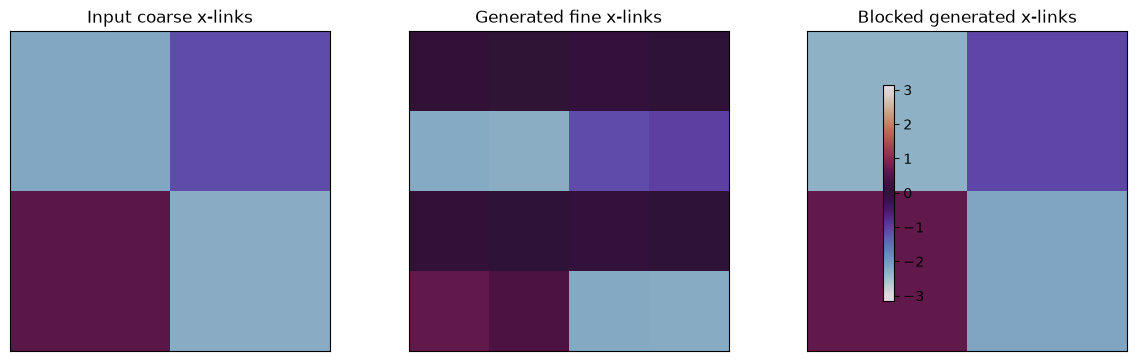

In [6]:
coarse_x = coarse_demo[0, 0].detach().cpu()
generated_fine_x = step_result.generated_fine_ensemble[0, 0]
blocked_generated_x = step_result.blocked_generated_ensemble[0, 0]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, image, title in zip(
    axes,
    [coarse_x, generated_fine_x, blocked_generated_x],
    ["Input coarse x-links", "Generated fine x-links", "Blocked generated x-links"],
):
    im = ax.imshow(image, cmap="twilight", vmin=-3.1416, vmax=3.1416)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
fig.tight_layout()
plt.show()